In [21]:
import pickle, gzip
import pandas as pd
import numpy as np
import copy
from pathlib import Path
from itertools import zip_longest

import seaborn as sns
import matplotlib.pyplot as plt

from utilities import *

In [22]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [23]:
def load_y_and_params(path, compressed=True):
    opener = gzip.open if compressed else open
    with opener(path, "rb") as f:
        payload = pickle.load(f)
    return payload["y"], payload["params"]

In [24]:
with open('../results/data/mix/r2_mix.pkl','rb') as f:
    r2_mix = pickle.load(f)

In [25]:
with open('../results/data/cmodel/r2_Cmodel.pkl','rb') as f:
    r2_cmodel = pickle.load(f)

In [26]:
with open('../results/data/tmodel/r2_Tmodel.pkl','rb') as f:
    r2_tmodel = pickle.load(f)

In [42]:
len(r2_tmodel)

50

In [27]:
df = pd.DataFrame(zip_longest(r2_mix, r2_cmodel, r2_tmodel), columns=['Mix Model', 'C model', 'T model'])

/lsf_tmp/278459617.tmpdir/ipykernel_1419589/2495201174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


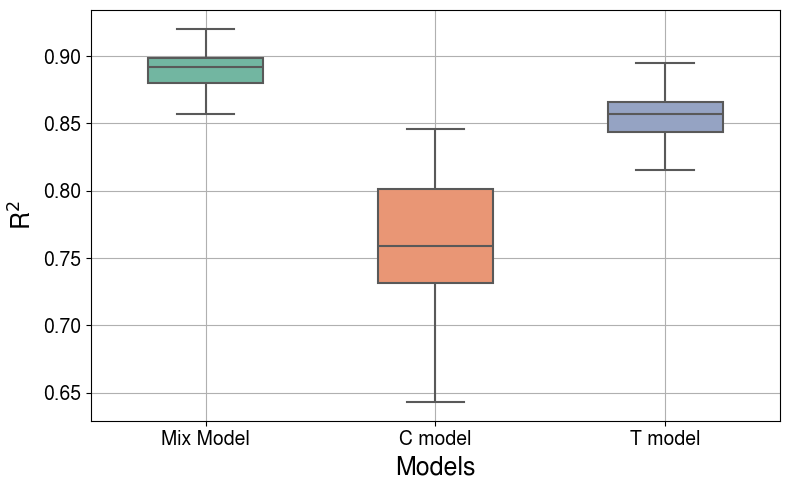

In [28]:
df_long = df.melt(var_name="Variable", value_name="Value")

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_long,
    x="Variable",
    y="Value",
    showfliers=False,    
    palette="Set2",
    width=0.5,
    linewidth=1.5
)
plt.xlabel("Models", fontsize=18)
plt.ylabel("R$^2$", fontsize=18)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.grid()
plt.tight_layout()
# plt.title("R$^2$ vs. Models ")
plt.savefig('../results/figures/summary/r2_all.pdf')

In [29]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')

In [30]:
data_f = data_copy.groupby('SCCRIP_ID').filter(lambda x: len(x) >= 5)

In [31]:
v1, p1 = len(data_f), len(data_f['SCCRIP_ID'].unique())

In [32]:
ctxn = read_sas('../data/Apply_MI_Zheng_2023_01/ctxn.sas7bdat')
ids = list(ctxn['SCCRIP_ID'].unique())
data_copy_f = data_copy[~data_copy['SCCRIP_ID'].isin(ids)]

In [33]:
data_f2 = data_copy_f.groupby('SCCRIP_ID').filter(lambda x: len(x) >= 5)

In [34]:
v2, p2 = len(data_f2), len(data_f2['SCCRIP_ID'].unique())

Text(0.5, 1.0, 'Couts of Visit')

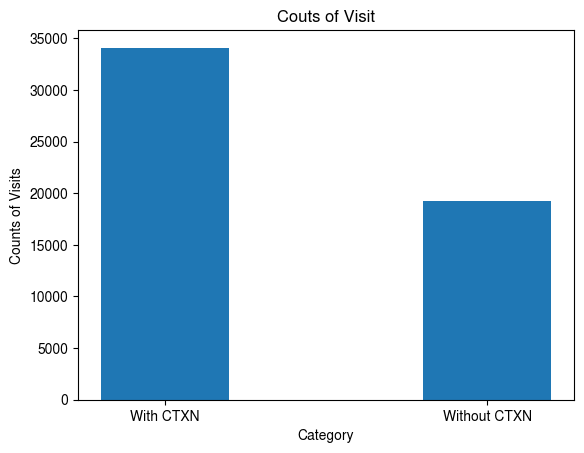

In [35]:
plt.bar(['With CTXN', 'Without CTXN'], [v1, v2], width=0.4)

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Counts of Visits')
plt.title('Couts of Visit')

Text(0.5, 1.0, 'Number of Patients')

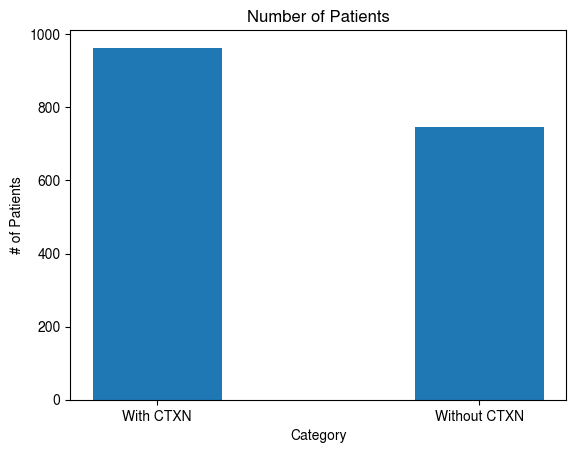

In [36]:
plt.bar(['With CTXN', 'Without CTXN'], [p1, p2], width=0.4)

# Add labels and title
plt.xlabel('Category')
plt.ylabel('# of Patients')
plt.title('Number of Patients')

In [37]:
data_copy_nohu = data_copy[data_copy['HU_status']==0]
data_copy_hu = data_copy[data_copy['HU_status']!=0]

data_hu = data_copy_hu.groupby('SCCRIP_ID').filter(lambda x: len(x) >= 5)
data_nohu = data_copy_nohu.groupby('SCCRIP_ID').filter(lambda x: len(x) >= 5)

In [38]:
vhu, phu = len(data_hu ), len(data_hu ['SCCRIP_ID'].unique())
vnohu, pnohu = len(data_nohu ), len(data_nohu ['SCCRIP_ID'].unique())

Text(0.5, 1.0, 'Couts of Visit')

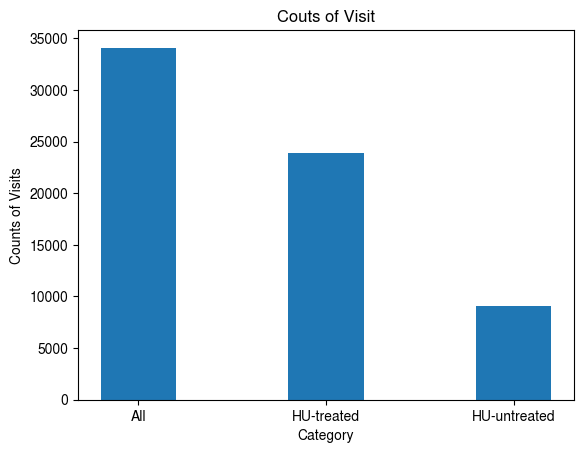

In [39]:
plt.bar(['All', 'HU-treated', 'HU-untreated'], [v1, vhu, vnohu], width=0.4)

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Counts of Visits')
plt.title('Couts of Visit')

Text(0.5, 1.0, 'Number of Patients')

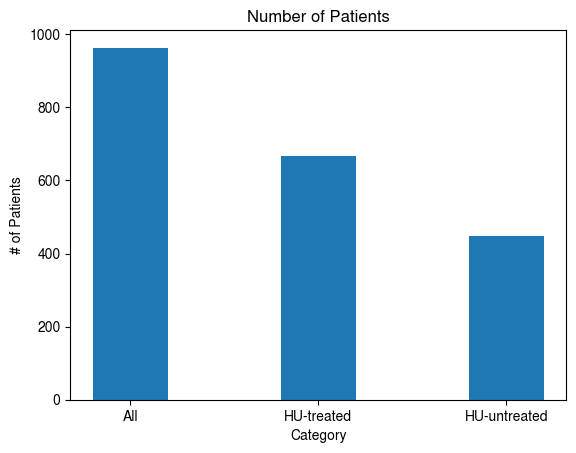

In [40]:
plt.bar(['All', 'HU-treated', 'HU-untreated'], [p1, phu, pnohu], width=0.4)

# Add labels and title
plt.xlabel('Category')
plt.ylabel('# of Patients')
plt.title('Number of Patients')